Starting for 2025 now for HI!!! LET'S DO THIS

In [1]:
# Import Libraries
import os
import earthaccess
import numpy as np
import geopandas as gpd
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# QC flag codes -- from singleband_raster_hierarchy() in create_frcov_masks.py,
# https://github.com/emit-sds/emit-sds-frcov (not formally published in the User Guide).
# Hierarchical: each pixel gets the FIRST condition below that applies to it.
flag_labels = {
    0: "clear",
    1: "cloud_or_cirrus",
    2: "urban",
    3: "water_or_coastal",
    4: "snow_ice",
}  # -9999 = nodata (outside scene footprint); handled separately via masked=True on load

flag_colors = ["#2ca02c", "#7f7f7f", "#d62728", "#1f77b4", "#f2f2f2"]
cmap = ListedColormap(flag_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

In [3]:
# Authenticate with NASA Earthdata (reads ~/.netrc, or prompts + persists on first run)
auth = earthaccess.login(persist=True)

In [4]:
# EMIT L2B Fractional Cover & Uncertainty (60 m, V001) over Maui.
# Currently narrowed to the exact acquisition date (2025-08-17) of the granule from
# https://search.earthdata.nasa.gov/...&g=G3991818701-LPCLOUD -- widen `temporal`
# (e.g. back to a month-long window) to search more broadly.
bbox = (-160.245911, 18.910690, -154.806622, 22.232707)  # (lon_min, lat_min, lon_max, lat_max) i.e., (West, South, East, North) in decimal degrees/boundaries
temporal = ("2025-01-31", "2025-12-31")  # (start_date, end_date) in YYYY-MM-DD format

results = earthaccess.search_data(
    concept_id="C3911089796-LPCLOUD",  # EMIT_L2BFRCOV.001 collection (LPCLOUD)
    bounding_box=bbox,
    temporal=temporal,
)

print(f"Found {len(results)} granule(s)")

Found 62 granule(s)


/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


Wow! 62 GRANULES?! This is going to be good

In [5]:
# Print every file (granule ID + all associated data/browse links) found in the search
for granule in results:
    print(granule["meta"]["native-id"])
    for link in granule.data_links():
        print(f"  {link}")

EMIT_L2B_FRCOV_001_20250324T233734_2508315_001
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250324T233734_2508315_001/EMIT_L2B_FRCOVQC_001_20250324T233734_2508315_001.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250324T233734_2508315_001/EMIT_L2B_FRCOVPV_001_20250324T233734_2508315_001.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250324T233734_2508315_001/EMIT_L2B_FRCOVPVUNC_001_20250324T233734_2508315_001.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250324T233734_2508315_001/EMIT_L2B_FRCOVNPV_001_20250324T233734_2508315_001.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20250324T233734_2508315_001/EMIT_L2B_FRCOVNPVUNC_001_20250324T233734_2508315_001.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-p

## Step 2: Locally download granules of interest

For every granule the search above found, there are 7 GeoTIFFs to download. Load them into one
 `xarray.Dataset`, and apply the QC band as a mask across the fraction
(PV/NPV/BARE) and uncertainty bands.

In [6]:
def download_and_reconcile(granule):
    """Download a granule's 7 GeoTIFFs, load into one aligned Dataset, mask
    fraction + uncertainty bands to QC-clear pixels (qc == 0). Returns (ds, ds_clear).
    QC flag source: create_frcov_masks.py in github.com/emit-sds/emit-sds-frcov."""
    granule_id = granule["meta"]["native-id"]
    out_dir = os.path.join("data", "emit_fcov", granule_id)
    os.makedirs(out_dir, exist_ok=True)
    files = earthaccess.download([granule], local_path=out_dir)

    roles = {}
    for f in files:
        name = os.path.basename(f)
        if "FRCOVQC" in name:
            roles["qc"] = f
        elif "FRCOVPVUNC" in name:
            roles["pv_unc"] = f
        elif "FRCOVNPVUNC" in name:
            roles["npv_unc"] = f
        elif "FRCOVBAREUNC" in name:
            roles["bare_unc"] = f
        elif "FRCOVPV" in name:
            roles["pv"] = f
        elif "FRCOVNPV" in name:
            roles["npv"] = f
        elif "FRCOVBARE" in name:
            roles["bare"] = f
    assert len(roles) == 7, f"Expected 7 bands, matched {len(roles)}: {roles}"

    g_ds = xr.Dataset(
        {role: rxr.open_rasterio(path, masked=True).squeeze("band", drop=True)
         for role, path in roles.items()}
    )

    clear = g_ds["qc"] == 0  # only unflagged pixels are retrieval-valid per the ATBD mask hierarchy
    g_ds_clear = g_ds.copy()
    for v in ["pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]:
        g_ds_clear[v] = g_ds[v].where(clear)

    return g_ds, g_ds_clear

In [7]:
# Process every granule the search found (not just one hardcoded scene) so this
# notebook still works if you change the bbox/temporal window above.
granules = {}
for g in results:
    gid = g["meta"]["native-id"]
    print(f"Processing {gid} ...")
    g_ds, g_ds_clear = download_and_reconcile(g)
    granules[gid] = (g_ds, g_ds_clear)

    total = int(g_ds["qc"].notnull().sum())
    n_clear = int((g_ds["qc"] == 0).sum())
    print(f"  {n_clear}/{total} pixels clear ({100 * n_clear / total:.1f}%)")

print(f"\nReconciled {len(granules)} granule(s).")

Processing EMIT_L2B_FRCOV_001_20250324T233734_2508315_001 ...


/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

...

/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

  42146/1976647 pixels clear (2.1%)

Reconciled 62 granule(s).


# Mosaic All Scenes

Merge every granule's QC-masked Dataset into one continuous mosaic. Works for any number
of granules (1..N) — if the search above returns a single scene the "mosaic" is just
that scene; if it returns several, they all get merged into one.

In [8]:
mosaic_vars = ["qc", "pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]

ds_mosaic = xr.Dataset({
    v: merge_arrays([g_ds_clear[v] for _, g_ds_clear in granules.values()], nodata=np.nan)
    for v in mosaic_vars
})

print(f"Mosaicked {len(granules)} scene(s) -> shape {ds_mosaic['pv'].shape}")

frac_sum = ds_mosaic["pv"] + ds_mosaic["npv"] + ds_mosaic["bare"]
print(f"Mosaic PV+NPV+BARE (clear pixels) -> mean: {float(frac_sum.mean(skipna=True)):.4f}, "
      f"std: {float(frac_sum.std(skipna=True)):.4f} (should be ~1.0 / ~0)")

Mosaicked 62 scene(s) -> shape (10079, 14019)
Mosaic PV+NPV+BARE (clear pixels) -> mean: 1.0000, std: 0.0000 (should be ~1.0 / ~0)


In [9]:
print(ds_mosaic.nbytes / 1e9, "GB")
print(ds_mosaic.dims)

7.347662844 GB
FrozenMappingWarningOnValuesAccess({'x': 14019, 'y': 10079})


going to coarsen it by factors of 30, 20, 10, 5, and 3

In [9]:
factor = 30  # try 20 if this still crashes, or 5 if you want more detail

def prep(band):
    return ds_mosaic[band].fillna(0).coarsen(x=factor, y=factor, boundary="trim").mean()

rgb_mosaic = xr.concat([prep("bare"), prep("pv"), prep("npv")], dim="band").transpose("y", "x", "band")
rgb_mosaic = rgb_mosaic.compute()

qc_small = ds_mosaic["qc"].coarsen(x=factor, y=factor, boundary="trim").mean().compute()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


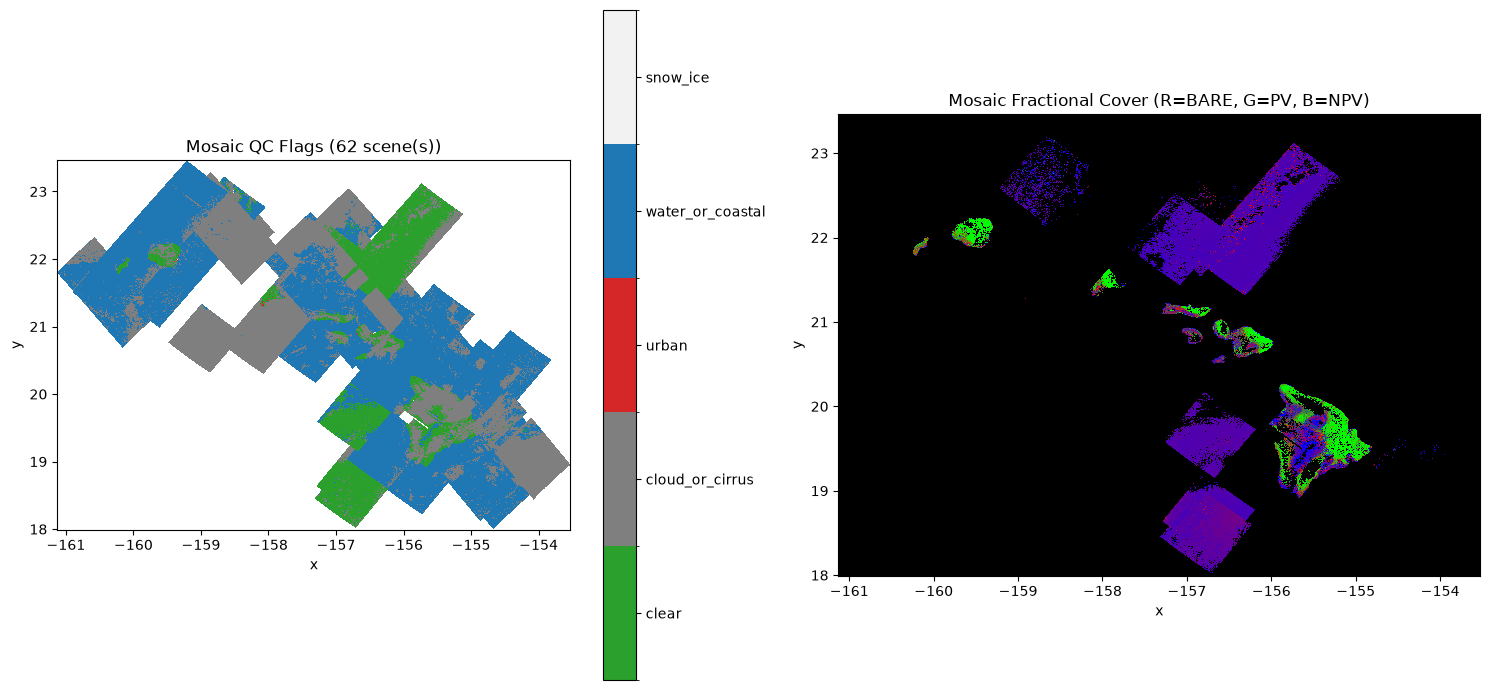

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = ds_mosaic["qc"].plot.imshow(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title(f"Mosaic QC Flags ({len(granules)} scene(s))")
axes[0].set_aspect("equal")
cbar = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(list(flag_labels.values()))

rgb_mosaic = xr.concat(
    [ds_mosaic["bare"].fillna(0), ds_mosaic["pv"].fillna(0), ds_mosaic["npv"].fillna(0)],
    dim="band",
).transpose("y", "x", "band")

rgb_mosaic.plot.imshow(ax=axes[1], rgb="band")
axes[1].set_title("Mosaic Fractional Cover (R=BARE, G=PV, B=NPV)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

Export Mosaic (Analysis-Ready GeoTIFFs)

In [11]:
export_dir = os.path.join("data", "processed")
os.makedirs(export_dir, exist_ok=True)

for var in mosaic_vars:
    out_path = os.path.join(export_dir, f"emit_2025HIfcov_mosaic_{var}.tif")
    da = ds_mosaic[var]
    # qc is integer-dtype -- reuse its native -9999 nodata sentinel (see flag_labels
    # comment above) since NaN isn't representable in an int raster. Everything else
    # (fraction + uncertainty bands) is float, so NaN is fine.
    nodata = -9999 if var == "qc" else np.nan
    # Both attrs and encoding can carry a stale _FillValue (attrs from write_nodata()
    # below, encoding inherited from open_rasterio(masked=True) via merge_arrays) --
    # to_raster()'s CF encoder refuses to reconcile them itself, so clear both first.
    da.attrs.pop("_FillValue", None)
    da.encoding.pop("_FillValue", None)
    if var == "qc":
        da = da.fillna(nodata).astype("int16")
    da.rio.write_nodata(nodata, inplace=True)
    da.rio.to_raster(out_path, compress="LZW")
    print(f"Wrote {out_path}")

Wrote data/processed/emit_2025HIfcov_mosaic_qc.tif
Wrote data/processed/emit_2025HIfcov_mosaic_pv.tif
Wrote data/processed/emit_2025HIfcov_mosaic_npv.tif
Wrote data/processed/emit_2025HIfcov_mosaic_bare.tif
Wrote data/processed/emit_2025HIfcov_mosaic_pv_unc.tif
Wrote data/processed/emit_2025HIfcov_mosaic_npv_unc.tif
Wrote data/processed/emit_2025HIfcov_mosaic_bare_unc.tif


Preliminary Stats

In [21]:
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var].compute()
    unc = ds_mosaic[f"{var}_unc"].compute()
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

        mean  median     std  min  max  mean_uncertainty
band                                                    
pv    0.1273  0.0000  0.2923  0.0  1.0            0.0627
npv   0.5755  0.6831  0.2471  0.0  1.0            0.3572
bare  0.2972  0.3002  0.1407  0.0  1.0            0.3327


In [22]:
# Dominant cover class per pixel (whichever of PV/NPV/BARE has the highest fraction there)
stacked = xr.concat(
    [ds_mosaic["pv"], ds_mosaic["npv"], ds_mosaic["bare"]], dim="band"
).assign_coords(band=["pv", "npv", "bare"])
dominant = stacked.idxmax(dim="band")

n_valid = int(dominant.notnull().sum())
print(f"\nDominant cover class ({n_valid} clear pixels):")
for label in ["pv", "npv", "bare"]:
    n = int((dominant == label).sum())
    print(f"  {label:5s}: {n:8d}  ({100 * n / n_valid:5.1f}%)")


Dominant cover class (13316713 clear pixels):
  pv   :  1739250  ( 13.1%)
  npv  : 10735785  ( 80.6%)
  bare :   841678  (  6.3%)


will repeat what we did for clipping qc flag water & for mosaic fcov

In [12]:
import rasterio
import numpy as np

qc_path = "data/processed/emit_2025HIfcov_mosaic_qc.tif"

with rasterio.open(qc_path) as src:
    qc = src.read(1)
    profile = src.profile

# Boolean mask: True where it's water/coastal (ocean)
ocean_mask = (qc == 3)

# Example: apply this mask to your fractional cover data to exclude oceans
# (assuming ds_mosaic[var] is one of your frcov variables, same shape as qc)
frcov_masked = np.where(ocean_mask, np.nan, ds_mosaic[var].values)

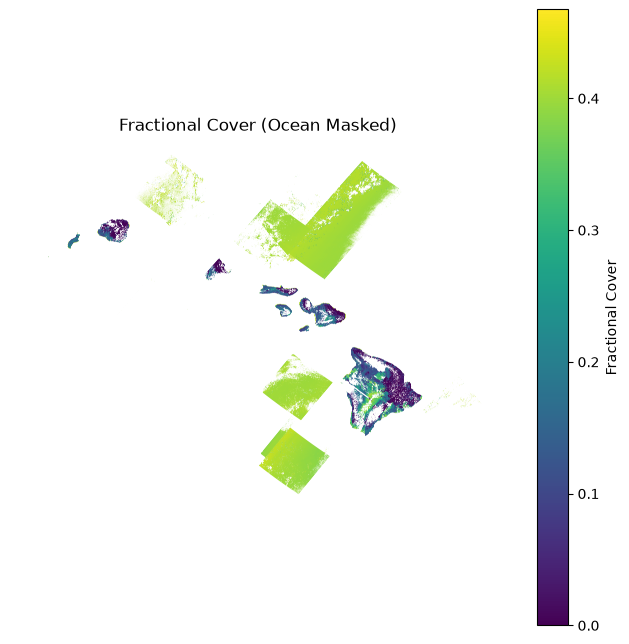

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(frcov_masked, cmap="viridis")
plt.colorbar(label="Fractional Cover")
plt.title("Fractional Cover (Ocean Masked)")
plt.axis("off")
plt.show()

see this still shows where there's "ground" where the ocean is there so mama we got to mask this out.

Clipping the QC Geotif using the shapefile

In [14]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask

# --- Paths ---
shp_path = "/Users/gillopez/Downloads/Coastline/Coastline.shp"  # from earlier download
qc_path = "data/processed/emit_2025HIfcov_mosaic_qc.tif"
out_path = "data/processed/emit_2025HIfcov_mosaic_qc_clipped.tif"

# --- Load shapefile ---
gdf = gpd.read_file(shp_path)

# --- Open raster and match CRS ---
with rasterio.open(qc_path) as src:
    raster_crs = src.crs

    # Reproject shapefile to match raster CRS if needed
    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)

    # --- Clip ---
    out_image, out_transform = mask(
        src,
        gdf.geometry,
        crop=True,        # crop the raster extent to the shape's bounding box
        nodata=-9999,      # matches your QC nodata convention
        filled=True
    )
    out_meta = src.meta.copy()

# --- Update metadata to match clipped shape/transform ---
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": -9999
})

# --- Write clipped GeoTIFF ---
with rasterio.open(out_path, "w", **out_meta) as dst:
    dst.write(out_image)

print(f"Clipped raster saved to {out_path}")

Clipped raster saved to data/processed/emit_2025HIfcov_mosaic_qc_clipped.tif


Clipped raster saved to data/processed/emit_2025HIfcov_mosaic_qc_clipped.tif
Fix: mask out nodata + use the discrete/categorical plotting approach from earlier

QC values present: [np.int16(0), np.int16(1), np.int16(2), np.int16(3), np.int16(4)]


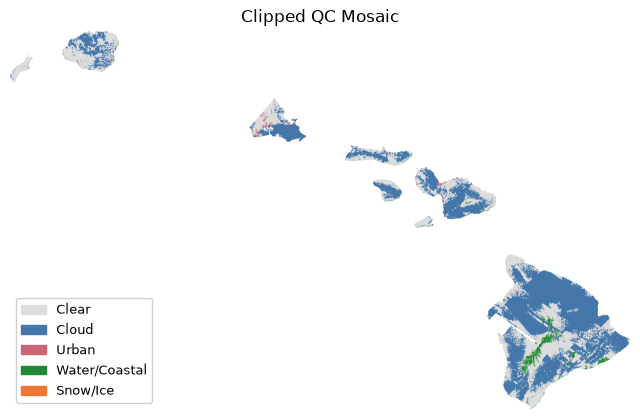

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio

with rasterio.open(out_path) as src:  # your clipped file
    qc = src.read(1)
    nodata_val = src.nodata

# --- Mask out nodata so it doesn't dominate the color scale ---
qc_masked = np.ma.masked_equal(qc, nodata_val)

# --- QC categories ---
qc_labels = {
    0: ("Clear", "#dddddd"),
    1: ("Cloud", "#4477AA"),
    2: ("Urban", "#CC6677"),
    3: ("Water/Coastal", "#228833"),
    4: ("Snow/Ice", "#EE7733"),
}

present_values = sorted(v for v in np.unique(qc_masked.compressed()) if v in qc_labels)
print("QC values present:", present_values)

colors = [qc_labels[v][1] for v in present_values]
labels = [qc_labels[v][0] for v in present_values]
cmap = ListedColormap(colors)
cmap.set_bad(color="white")  # nodata shows as white instead of a "color"

bounds = present_values + [present_values[-1] + 1]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8, 8))
plt.imshow(qc_masked, cmap=cmap, norm=norm)
plt.title("Clipped QC Mosaic")
plt.axis("off")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
plt.legend(handles=patches, loc="lower left", fontsize=9, framealpha=0.9)
plt.show()

1. Clip and mask each fractional cover band

In [16]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

# --- Paths ---
shp_path = "/Users/gillopez/Downloads/Coastline/Coastline.shp"  # from earlier download
qc_path = "data/processed/emit_2025HIfcov_mosaic_qc.tif"
bare_path = "data/processed/emit_2025HIfcov_mosaic_bare.tif"
pv_path = "data/processed/emit_2025HIfcov_mosaic_pv.tif"
npv_path = "data/processed/emit_2025HIfcov_mosaic_npv.tif"

gdf = gpd.read_file(shp_path)

def clip_raster(path, gdf, nodata_val):
    with rasterio.open(path) as src:
        gdf_reproj = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf
        out_image, out_transform = mask(
            src, gdf_reproj.geometry, crop=True, nodata=nodata_val, filled=True
        )
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": nodata_val
        })
    return out_image[0], out_meta  # single band

# --- Clip QC and each fractional cover band ---
qc_clipped, qc_meta = clip_raster(qc_path, gdf, -9999)
bare_clipped, bare_meta = clip_raster(bare_path, gdf, np.nan)
pv_clipped, pv_meta = clip_raster(pv_path, gdf, np.nan)
npv_clipped, npv_meta = clip_raster(npv_path, gdf, np.nan)

print("Shapes match:", qc_clipped.shape == bare_clipped.shape == pv_clipped.shape == npv_clipped.shape)

Shapes match: True


2. Apply the ocean mask (QC == 3) on top of the clip

In [17]:
# --- Ocean mask: True where water/coastal ---
ocean_mask = (qc_clipped == 3)

# --- Apply mask to each band ---
bare_masked = np.where(ocean_mask, np.nan, bare_clipped)
pv_masked = np.where(ocean_mask, np.nan, pv_clipped)
npv_masked = np.where(ocean_mask, np.nan, npv_clipped)

3. Build and normalize the RGB composite

In [18]:
def normalize(band):
    band = np.nan_to_num(band, nan=0.0)
    band_min, band_max = np.nanmin(band), np.nanmax(band)
    if band_max - band_min == 0:
        return np.zeros_like(band)
    return (band - band_min) / (band_max - band_min)

r = normalize(bare_masked)  # BARE
g = normalize(pv_masked)    # PV
b = normalize(npv_masked)   # NPV

rgb = np.dstack([r, g, b])

4. Plot it

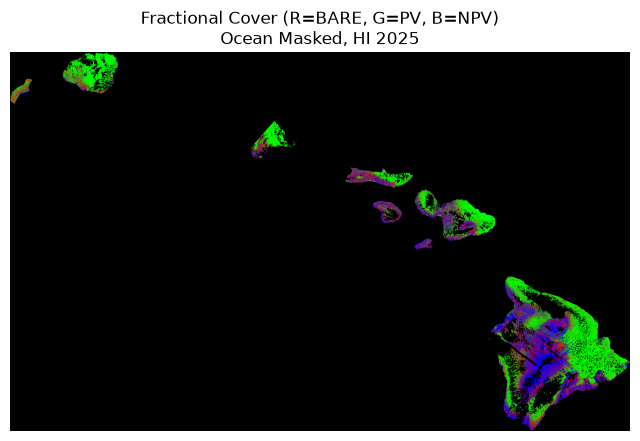

In [19]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("Fractional Cover (R=BARE, G=PV, B=NPV)\nOcean Masked, HI 2025")
plt.axis("off")
plt.show()

we're going to add the default coordinate extent to the RGB plot ^ above

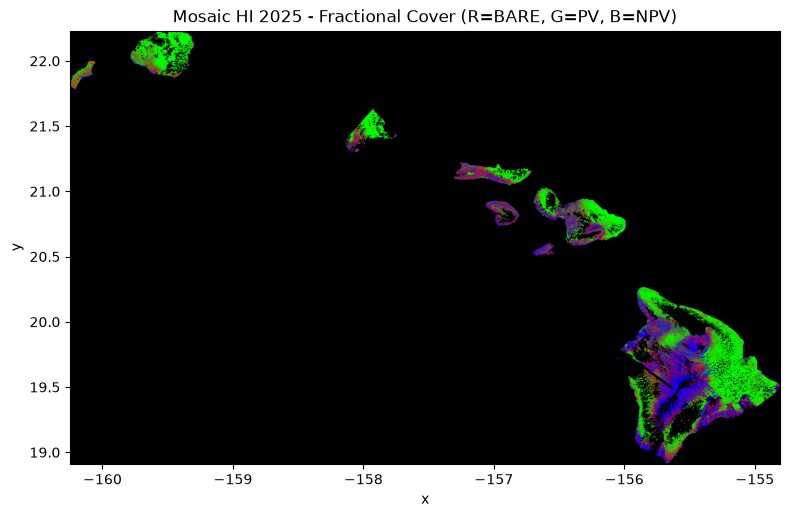

In [21]:
import matplotlib.pyplot as plt

# --- Get geographic bounds from the clipped raster's metadata ---
transform = bare_meta["transform"]
height, width = bare_masked.shape

left = transform.c
top = transform.f
right = left + width * transform.a
bottom = top + height * transform.e  # transform.e is negative

extent = [left, right, bottom, top]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb, extent=extent)
ax.set_title("Mosaic HI 2025 - Fractional Cover (R=BARE, G=PV, B=NPV)")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()

1. Saving mean values of fcov into 1 csv file! Similar to '23 & '24

In [22]:
import pandas as pd
import os

# --- Your existing stats code ---
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var].compute()
    unc = ds_mosaic[f"{var}_unc"].compute()
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

# --- Flatten into one row for the shared summary file ---
year = 2025      # <-- change per notebook
region = "HI"    # <-- change to "CA" in the CA notebooks

summary_row = {"year": year, "region": region}
for band in ["pv", "npv", "bare"]:
    summary_row[f"{band}_mean"] = stats_df.loc[band, "mean"]

summary_path = "data/processed/landcover_mean_summary.csv"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)

if os.path.exists(summary_path):
    df_existing = pd.read_csv(summary_path)
    df_existing = df_existing[~((df_existing["year"] == year) & (df_existing["region"] == region))]
    df_updated = pd.concat([df_existing, pd.DataFrame([summary_row])], ignore_index=True)
else:
    df_updated = pd.DataFrame([summary_row])

df_updated.to_csv(summary_path, index=False)
print(f"Saved {region} {year} summary")
print(df_updated)

        mean  median     std  min  max  mean_uncertainty
band                                                    
pv    0.1273  0.0000  0.2923  0.0  1.0            0.0627
npv   0.5755  0.6831  0.2471  0.0  1.0            0.3572
bare  0.2972  0.3002  0.1407  0.0  1.0            0.3327
Saved HI 2025 summary
   year region   pv_mean  npv_mean  bare_mean
0  2023     HI  0.097437  0.624778   0.277785
1  2024     HI  0.112193  0.616784   0.271024
2  2025     HI  0.127275  0.575486   0.297239
